<a href="https://colab.research.google.com/github/rb7488/Binaire-assement/blob/main/Binaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 24.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0


In [5]:
from huggingface_hub import HfApi

api = HfApi()

organization = "freznelai"

models = list(api.list_models(author=organization))

print("Models found:", len(models))

for i, model in enumerate(models, 1):
    print(i, model.id)

Models found: 2
1 freznelai/FreznelAI_1.0_Face-Landmarker_500M_FZFP4_FRZm
2 freznelai/FreznelAI_1.0_Face-Detector_500M_FZFP4_FRZm


In [6]:
from huggingface_hub import snapshot_download
from pathlib import Path

models_dir = Path("/content/models")
models_dir.mkdir(exist_ok=True)

for model in models:
    model_name = model.id.split("/")[-1]
    destination = models_dir / model_name

    print(f"Downloading: {model.id}")

    snapshot_download(
        repo_id=model.id,
        repo_type="model",
        local_dir=str(destination)
    )

    print(f"Completed: {model.id}\n")

Downloading: freznelai/FreznelAI_1.0_Face-Landmarker_500M_FZFP4_FRZm


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Completed: freznelai/FreznelAI_1.0_Face-Landmarker_500M_FZFP4_FRZm

Downloading: freznelai/FreznelAI_1.0_Face-Detector_500M_FZFP4_FRZm


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Completed: freznelai/FreznelAI_1.0_Face-Detector_500M_FZFP4_FRZm



In [7]:
import os

for root, dirs, files in os.walk("/content/models"):
    level = root.replace("/content/models", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

models/
  FreznelAI_1.0_Face-Landmarker_500M_FZFP4_FRZm/
    .gitattributes
    README.md
    FreznelAI_1.0_Face-Landmarker_500M_FZFP4.frzm
    .cache/
      huggingface/
        .gitignore
        CACHEDIR.TAG
        download/
          README.md.metadata
          FreznelAI_1.0_Face-Landmarker_500M_FZFP4.frzm.metadata
          README.md.lock
          FreznelAI_1.0_Face-Landmarker_500M_FZFP4.frzm.lock
          .gitattributes.metadata
          .gitattributes.lock
        trees/
          c2565839386b9ba473f8162c35b6a8cf65333223.json
  FreznelAI_1.0_Face-Detector_500M_FZFP4_FRZm/
    .gitattributes
    README.md
    FreznelAI_1.0_Face-Detector_500M_FZFP4.frzm
    .cache/
      huggingface/
        .gitignore
        CACHEDIR.TAG
        download/
          README.md.metadata
          FreznelAI_1.0_Face-Detector_500M_FZFP4.frzm.metadata
          README.md.lock
          .gitattributes.metadata
          FreznelAI_1.0_Face-Detector_500M_FZFP4.frzm.lock
          .gitattributes.lock

# Scrapping


In [8]:
!pip install beautifulsoup4 pandas xml

ERROR: Could not find a version that satisfies the requirement xml (from versions: none)
ERROR: No matching distribution found for xml


In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from urllib.parse import urljoin

In [11]:
BASE_URL = "https://www.lexaloffle.com"
START_URL = "https://www.lexaloffle.com/bbs/?cat=7&carts_tab=1&sub=2&mode=carts"

print("Source:", START_URL)

Source: https://www.lexaloffle.com/bbs/?cat=7&carts_tab=1&sub=2&mode=carts


In [21]:
first_game_url = game_links[0]["url"]

game_response = requests.get(
    first_game_url,
    headers=headers,
    timeout=30
)

print("URL:", first_game_url)
print("Status code:", game_response.status_code)
print("Page size:", len(game_response.text))

URL: https://www.lexaloffle.com/bbs/?tid=159194
Status code: 200
Page size: 130367


In [22]:
game_soup = BeautifulSoup(game_response.text, "lxml")

print(game_soup.title.get_text(" ", strip=True))

"The Zone"


In [23]:
text = game_soup.get_text("\n", strip=True)

print(text[:5000])

"The Zone"
Log In
PICO-8
FAQ
Resources
Schools
Submit
Forum
Carts
PICO-8
FAQ
Resources
Schools
Submit
Forum
Carts
Log In
User:
Password:
New User
|
Account Help
"The Zone"
squishyam
•
2026-09-10*
2026-09-10 02:33*
•
BBS
>
PICO-8
>
Cartridges
Subscribe to this Thread
(Receive email notifications)
Pin To Profile
"The Zone"
Cart File
|
Forum Post
|
More cartridges
by
squishyam
More Cartridges
[View All]
"The Zone"
by
squishyam
Cart
#weyubomopo-0

								|
2026-09-10
|
Code ▽
|
Embed ▽
|
License:
CC4-BY-NC-SA
1
Copy and paste the snippet below into your HTML.
<iframe src="https://www.lexaloffle.com/bbs/widget.php?pid=weyubomopo" allowfullscreen width="621" height="513" style="border:none; overflow:hidden"></iframe>
PICO-1K Jam 2026
1
[Please log in to post a comment]
About
|
Contact
|
Updates
|
Terms of Use
Follow Lexaloffle:
Generated 2026-09-10 06:26:20 |
				0.013s | 
				Q:12


In [24]:
matches = game_soup.find_all(
    string=lambda text: text and "The Zone" in text
)

print("Matches found:", len(matches))

for i, match in enumerate(matches[:20], 1):
    print(f"\n--- Match {i} ---")
    print("Text:", repr(match.strip()))
    print("Parent:", match.parent.name)
    print("Parent class:", match.parent.get("class"))
    print("Parent id:", match.parent.get("id"))

Matches found: 5

--- Match 1 ---
Text: '"The Zone"'
Parent: title
Parent class: None
Parent id: None

--- Match 2 ---
Text: '"The Zone"'
Parent: a
Parent class: None
Parent id: None

--- Match 3 ---
Text: '"The Zone"'
Parent: div
Parent class: None
Parent id: None

--- Match 4 ---
Text: '"The Zone"'
Parent: a
Parent class: None
Parent id: None

--- Match 5 ---
Text: 'p_sub = 0;\n\t\tpdat=[\n\t[\'weyubomopo-0\', 159194, `&quot;The Zone&quot;`,"",,,"2026-09-10 02:33:24",135222,"squishyam","",0,"",,1,196003,7,2,\'0\',[],0,5,,``,``],\n\t\t];\n\t\tvar updat=[\n\t];\n\t\tsearch_url_base = "?sub=0&orderby=ts&search=";\n\t\ttag_url_base =    "/bbs/?cat=0#tag=";\n\t\t\n\t\tfunction make_stat_box(set_name, num, state, post_id, bg, margin)\n\t\t{\n\t\t\tvar imgf = set_name;\n\t\t\tif (state == 1)\n\t\t\t\timgf = imgf + `1.png`;\n\t\t\telse\n\t\t\t\timgf = imgf + `0.png`;\n\t\t\t\n\t\t\tvar s =\n\t\t\t`\n\t\t\t\t<div style="display:flex; background:`+bg+`; padding:6px;\n\t\t\t\t\talign-items: cen


==================== Code ====================
Text: 'function microAjax(B,A){this.bindFunction=function(E,D){return function(){return E.apply(D,[D])}};this.stateChange=function(D){if(this.request.readyState==4){this.callbackFunction(this.request.responseText)}};this.getRequest=function(){if(window.ActiveXObject){return new ActiveXObject("Microsoft.XMLHTTP")}else{if(window.XMLHttpRequest){return new XMLHttpRequest()}}return false};this.postBody=(arguments[2]||"");this.callbackFunction=A;this.url=B;this.request=this.getRequest();if(this.request){var C=this.request;C.onreadystatechange=this.bindFunction(this.stateChange,this);if(this.postBody!==""){C.open("POST",B,true);C.setRequestHeader("X-Requested-With","XMLHttpRequest");C.setRequestHeader("Content-type","application/x-www-form-urlencoded");C.setRequestHeader("Connection","close")}else{C.open("GET",B,true)}C.send(this.postBody)}};'
Parent: script
Class: None
ID: None
Text: '<!--\n\n@font-face {\n  font-family: \'proggyvec\';\n  src:
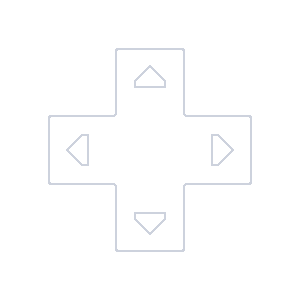
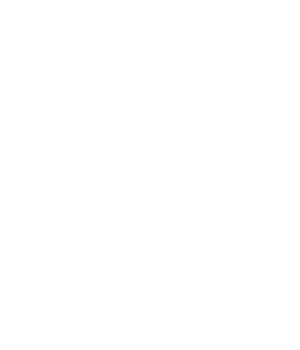

In [25]:
for keyword in ["Code", "License"]:
    print(f"\n{'='*20} {keyword} {'='*20}")

    matches = game_soup.find_all(
        string=lambda text: text and keyword.lower() in text.lower()
    )

    for match in matches[:10]:
        print("Text:", repr(match.strip()))
        print("Parent:", match.parent.name)
        print("Class:", match.parent.get("class"))
        print("ID:", match.parent.get("id"))

In [26]:
images = game_soup.find_all("img")

print("Total images:", len(images))

for i, img in enumerate(images, 1):
    print(
        f"{i}: "
        f"alt={img.get('alt')} | "
        f"src={img.get('src')} | "
        f"class={img.get('class')}"
    )

Total images: 37
1: alt=None | src=/gfx/top_pulldown.png | class=None
2: alt=None | src=/gfx/top_drop.png | class=None
3: alt=None | src=/gfx/top_info.png | class=None
4: alt=None | src=/gfx/p8b_pico8.png | class=None
5: alt=None | src=/gfx/p8b_vox.png | class=None
6: alt=None | src=/gfx/p8b_picotron.png | class=None
7: alt=None | src=/gfx/bbs_cube.gif | class=None
8: alt=None | src=/gfx/top_blog.png | class=None
9: alt=None | src=/gfx/top_info.png | class=None
10: alt=None | src=/gfx/p8b_pico8.png | class=None
11: alt=None | src=/gfx/p8b_vox.png | class=None
12: alt=None | src=/gfx/p8b_picotron.png | class=None
13: alt=None | src=/gfx/bbs_cube.gif | class=None
14: alt=None | src=/gfx/top_blog.png | class=None
15: alt=None | src=/gfx/top_drop.png | class=None
16: alt=None | src=/media/135222/3_buster.png | class=['avatar']
17: alt=None | src=/gfx/so_itch.png | class=None
18: alt=None | src=/gfx/top_drop.png | class=None
19: alt=None | src=/gfx/set_watch0.png | class=None
20: alt=None |

In [27]:
for link in game_soup.find_all("a", href=True):
    text = link.get_text(" ", strip=True)
    href = link["href"]

    if any(
        keyword in text.lower()
        for keyword in ["code", "download", "license", "embed", "cart"]
    ):
        print(f"TEXT: {text!r}")
        print(f"HREF: {href}")
        print("-" * 50)

TEXT: 'Carts'
HREF: /bbs/?cat=7&carts_tab=1&#sub=2&mode=carts
--------------------------------------------------
TEXT: 'Carts'
HREF: /bbs/?cat=7&carts_tab=1&#sub=2&mode=carts
--------------------------------------------------
TEXT: 'Cartridges'
HREF: /bbs/?cat=7#sub=2
--------------------------------------------------
TEXT: 'Cart File'
HREF: /bbs/cposts/we/weyubomopo-0.p8.png
--------------------------------------------------
TEXT: 'More cartridges'
HREF: https://www.lexaloffle.com/bbs/?uid=135222&mode=carts
--------------------------------------------------
TEXT: 'Cart'
HREF: /bbs/cposts/we/weyubomopo-0.p8.png
--------------------------------------------------


In [28]:
# Find all elements containing the word "License"
license_matches = game_soup.find_all(
    string=lambda text: text and "License:" in text
)

print("License matches:", len(license_matches))

for match in license_matches:
    print("\nTEXT:", repr(match.strip()))
    print("PARENT:", match.parent)

License matches: 1

TEXT: 'License:'
PARENT: <span class="desktop_div" style="color:#666">License:</span>


In [29]:
# Find elements containing "CC4-BY-NC-SA"
cc_matches = game_soup.find_all(
    string=lambda text: text and "CC4-BY-NC-SA" in text
)

print("CC matches:", len(cc_matches))

for match in cc_matches:
    print("\nTEXT:", repr(match.strip()))
    print("PARENT:", match.parent)

CC matches: 1

TEXT: 'CC4-BY-NC-SA'
PARENT: <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/" style="color:#aaa" target="_cc4">CC4-BY-NC-SA</a>


In [30]:
# Print divs that have IDs
for div in game_soup.find_all(["div", "section"], id=True):
    print(
        "TAG:", div.name,
        "| ID:", div.get("id"),
        "| CLASS:", div.get("class")
    )

TAG: div | ID: body_0 | CLASS: None
TAG: div | ID: lil_menu_pulldown | CLASS: None
TAG: div | ID: banner | CLASS: ['topmenu_div']
TAG: div | ID: m | CLASS: ['topmenu_div']
TAG: div | ID: account_pulldown | CLASS: None
TAG: div | ID: account_pulldown_inner | CLASS: None
TAG: div | ID: main_div | CLASS: None
TAG: div | ID: p8_desktop | CLASS: ['desktop_div']
TAG: div | ID: listing_page_nav | CLASS: None
TAG: div | ID: p | CLASS: None
TAG: div | ID: p196003 | CLASS: None
TAG: div | ID: set_extra_196003 | CLASS: None
TAG: div | ID: pweyubomopo-0 | CLASS: ['playarea_0']
TAG: div | ID: p8_frame_0 | CLASS: None
TAG: div | ID: p8_frame | CLASS: None
TAG: div | ID: cart_menu_weyubomopo-0 | CLASS: None
TAG: div | ID: more_carts_weyubomopo-0 | CLASS: None
TAG: div | ID: p8_menu_buttons_touch | CLASS: None
TAG: div | ID: p8b_full | CLASS: ['p8_menu_button']
TAG: div | ID: p8b_sound | CLASS: ['p8_menu_button']
TAG: div | ID: p8b_close | CLASS: ['p8_menu_button']
TAG: div | ID: p8_container | CLASS:


==================== comment ====================
TEXT: '<!--\n\n@font-face {\n  font-family: \'proggyvec\';\n  src: url(\'/proggyvec.woff\') format(\'woff\');\n\n}\n\n.banner_div{display:block}\n.topmenu_div{display:table}\n.lilmenu_div{display:none}\n.desktop_div{display:inline}\n.mobile_div{display:none}\n\n.avatar{\n\tborder-radius:10%;\n\tbox-shadow: 4px 4px 6px rgba(0.2, 0.0, 0.4, 0.1);\n}\n\n.avatar_tiny{\n\tborder-radius:20%;\n\tbox-shadow: 4px 4px 6px rgba(0.2, 0.0, 0.4, 0.1);\n}\n\n.scrollable_with_touch{\n\tmax-width:95vw; overflow-x:auto;overflow-y:hidden; -webkit-overflow-scrolling:touch;\n}\n.info_box {\ndisplay:table; float:left; margin-left:8px; margin-right:16px;\nmargin-top:0px; margin-bottom:16px; text-align:left;\n}\n\n.info_box_right_old {display:table; margin-left:16px; margin-right:8px;\nmargin-top:-10px; margin-bottom:16px; float:right; text-align:left;\n}\n\n.info_box_right {\n\tmargin-top:-10px;\n}\n\n\n.info_box h2 {margin-top:-16px;}\nh2 {margin-top:0px;}\n
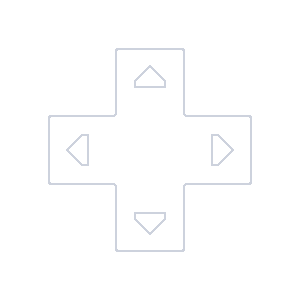
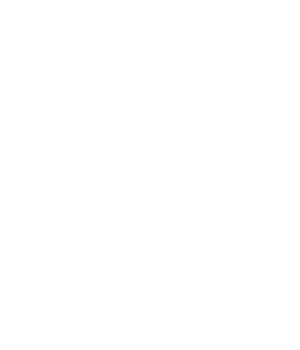

In [32]:
#find comments
comment_keywords = [
    "comment",
    "Please log in to post comment"
]

for keyword in comment_keywords:
    print(f"\n{'='*20} {keyword} {'='*20}")

    matches = game_soup.find_all(
        string=lambda text: text and keyword.lower() in text.lower()
    )

    for match in matches[:20]:
        print("TEXT:", repr(match.strip()))
        print("PARENT:", match.parent.name)
        print("CLASS:", match.parent.get("class"))
        print("ID:", match.parent.get("id"))

In [33]:
# Inspect the important content areas of the game page

print("===== MAIN CONTENT =====")
main = game_soup.find(id="p196003")
if main:
    print(main.get_text("\n", strip=True)[:5000])
else:
    print("Main content not found")


print("\n===== CART SOURCE =====")
cart_src = game_soup.find(id="cartsrc_weyubomopo-0")
if cart_src:
    print(cart_src.get_text("\n", strip=True)[:5000])
    print("HTML:")
    print(str(cart_src)[:3000])
else:
    print("Cart source not found")


print("\n===== CODE REFERENCES =====")
for match in game_response.text.splitlines():
    if "code" in match.lower() or "cartsrc" in match.lower():
        print(match[:1000])

===== MAIN CONTENT =====
"The Zone"
squishyam
•
2026-09-10*
2026-09-10 02:33*
•
BBS
>
PICO-8
>
Cartridges
Subscribe to this Thread
(Receive email notifications)
Pin To Profile
"The Zone"
Cart File
|
Forum Post
|
More cartridges
by
squishyam
More Cartridges
[View All]
"The Zone"
by
squishyam
Cart
#weyubomopo-0

								|
2026-09-10
|
Code ▽
|
Embed ▽
|
License:
CC4-BY-NC-SA
1
Copy and paste the snippet below into your HTML.
<iframe src="https://www.lexaloffle.com/bbs/widget.php?pid=weyubomopo" allowfullscreen width="621" height="513" style="border:none; overflow:hidden"></iframe>
PICO-1K Jam 2026
1

===== CART SOURCE =====

HTML:
<div id="cartsrc_weyubomopo-0" style="max-width:740px; border:0px; margin:0px; padding:0px; background-color:#224; display:none">
<iframe loading="lazy" src="/bbs/snippet.php?cart_id=weyubomopo-0&amp;src=1" style="width:100%; height:400px; border:none; overflow:hidden"></iframe>
</div>

===== CODE REFERENCES =====
function microAjax(B,A){this.bindFunction=funct

# TASK2


In [34]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from urllib.parse import urljoin, urlparse, parse_qs

BASE_URL = "https://www.lexaloffle.com"

START_URL = (
    "https://www.lexaloffle.com/bbs/"
    "?cat=7&carts_tab=1&sub=2&mode=carts"
)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/131.0 Safari/537.36"
    )
}

session = requests.Session()
session.headers.update(HEADERS)

print("Setup complete")

Setup complete


In [35]:
def get_game_links(page_number):
    """
    Get cartridge/thread links from one BBS page.
    """

    if page_number == 1:
        url = START_URL
    else:
        url = (
            f"{BASE_URL}/bbs/"
            f"?cat=7&orderby=ts&page={page_number}&sub=2"
        )

    response = session.get(url, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "lxml")

    games = []

    for link in soup.find_all("a", href=True):

        href = link.get("href", "").strip()
        name = link.get_text(" ", strip=True)

        if href.startswith("?tid=") and name:

            games.append({
                "name": name,
                "url": urljoin(BASE_URL + "/bbs/", href)
            })

    return games


# Collect games from multiple pages
all_games = []

for page in range(1, 10):

    print(f"Scraping listing page {page}...")

    try:
        page_games = get_game_links(page)

        if not page_games:
            print("No more games found.")
            break

        all_games.extend(page_games)

        print(f"  Found: {len(page_games)}")

        if len(all_games) >= 100:
            break

        time.sleep(1)

    except Exception as e:
        print("Error:", e)
        break


# Remove duplicate URLs
unique_games = []
seen_urls = set()

for game in all_games:

    if game["url"] not in seen_urls:
        unique_games.append(game)
        seen_urls.add(game["url"])


games = unique_games[:100]

print("\n==========================")
print("TOTAL GAMES:", len(games))
print("==========================")

for i, game in enumerate(games, 1):
    print(i, game["name"], "->", game["url"])

Scraping listing page 1...
  Found: 30
Scraping listing page 2...
  Found: 30
Scraping listing page 3...
  Found: 30
Scraping listing page 4...
  Found: 30

TOTAL GAMES: 100
1 "The Zone" -> https://www.lexaloffle.com/bbs/?tid=159194
2 Code Golf Snake -> https://www.lexaloffle.com/bbs/?tid=159193
3 FlappyBird -> https://www.lexaloffle.com/bbs/?tid=159182
4 pico pong -> https://www.lexaloffle.com/bbs/?tid=159181
5 Bouncing ball -> https://www.lexaloffle.com/bbs/?tid=159173
6 Retro Rewind Volume 1 -> https://www.lexaloffle.com/bbs/?tid=159156
7 Russian checkers -> https://www.lexaloffle.com/bbs/?tid=159152
8 "Shadow" -> https://www.lexaloffle.com/bbs/?tid=159149
9 pilatro_35 -> https://www.lexaloffle.com/bbs/?tid=159145
10 scoundrel-8 (prototype) -> https://www.lexaloffle.com/bbs/?tid=159144
11 Princess Mochi -> https://www.lexaloffle.com/bbs/?tid=159143
12 Lionfish Hunter 2026 -> https://www.lexaloffle.com/bbs/?tid=159135
13 Kairu -> https://www.lexaloffle.com/bbs/?tid=159133
14 Plight o

In [36]:
#helper funtion
def clean_text(text):
    if not text:
        return ""

    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def get_cart_id(html):
    """
    Extract PICO-8 cartridge ID from cartsrc_XXXX element.
    """

    match = re.search(r'id=["\']cartsrc_([^"\']+)', html)

    if match:
        return match.group(1)

    return ""


def get_artwork(soup):
    """
    Find PICO-8 cartridge artwork.
    """

    for img in soup.find_all("img", src=True):

        src = img["src"]

        if "/bbs/thumbs/" in src:
            return urljoin(BASE_URL, src)

    return ""


def get_license(soup):
    """
    Extract license information.
    """

    # Look for text containing License
    text = soup.get_text(" ", strip=True)

    match = re.search(
        r"License:\s*([A-Za-z0-9\-_]+)",
        text,
        re.IGNORECASE
    )

    if match:
        return match.group(1)

    # Fallback: Creative Commons link
    for a in soup.find_all("a", href=True):

        href = a.get("href", "")

        if "creativecommons.org" in href:

            return clean_text(a.get_text(" ", strip=True))

    return ""


def get_cart_code(cart_id):
    """
    Get actual PICO-8 source code from Lexaloffle snippet endpoint.
    """

    if not cart_id:
        return ""

    url = (
        f"{BASE_URL}/bbs/snippet.php"
        f"?cart_id={cart_id}&src=1"
    )

    try:

        response = session.get(
            url,
            timeout=30
        )

        if response.status_code == 200:

            return response.text.strip()

    except Exception:
        pass

    return ""


def get_description(soup):
    """
    Try to extract the forum post/game description.
    """

    # Main post container
    post = soup.find("div", id="p")

    if not post:
        return ""

    text = post.get_text("\n", strip=True)

    # Remove common navigation/UI text
    unwanted = [
        "Subscribe to this Thread",
        "Receive email notifications",
        "Pin To Profile",
        "Cart File",
        "Forum Post",
        "More cartridges",
        "More Cartridges",
        "View All",
        "Cart",
        "Embed",
        "Code",
        "License:"
    ]

    for item in unwanted:
        text = text.replace(item, "")

    return clean_text(text)


def get_comments(soup):
    """
    Extract visible comments from the page.
    Returns maximum 5 comments.
    """

    comments = []

    # Look for common comment/post containers
    possible_posts = soup.find_all(
        "div",
        id=re.compile(r"^p\d+")
    )

    for post in possible_posts:

        text = clean_text(
            post.get_text(" ", strip=True)
        )

        if not text:
            continue

        # Ignore main game post
        if len(text) < 10:
            continue

        # Ignore obvious UI text
        if "Please log in to post a comment" in text:
            continue

        comments.append(text)

    # Remove duplicates
    unique_comments = []

    for comment in comments:

        if comment not in unique_comments:
            unique_comments.append(comment)

    return unique_comments[:5]


def get_likes(soup, html):
    """
    Extract like count.

    First tries the page HTML/JS data,
    then looks around the like button.
    """

    # Try set_like elements / nearby numeric values
    like_elements = soup.find_all(
        id=re.compile(r"like", re.IGNORECASE)
    )

    for element in like_elements:

        text = clean_text(
            element.get_text(" ", strip=True)
        )

        match = re.search(r"\b(\d+)\b", text)

        if match:
            return int(match.group(1))

    # Search raw HTML for like-related data
    patterns = [
        r"likes?[\"']?\s*[:=]\s*[\"']?(\d+)",
        r"like_count[\"']?\s*[:=]\s*[\"']?(\d+)",
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            html,
            re.IGNORECASE
        )

        if match:
            return int(match.group(1))

    return 0

In [37]:
#Main Scarapper
def scrape_game(game):

    url = game["url"]

    print(f"Scraping: {game['name']}")

    try:

        response = session.get(
            url,
            timeout=30
        )

        response.raise_for_status()

        soup = BeautifulSoup(
            response.text,
            "lxml"
        )

        html = response.text

        # -------------------------
        # NAME
        # -------------------------

        name = game["name"]

        title = soup.find(
            "h1"
        )

        if title:
            possible_name = clean_text(
                title.get_text(" ", strip=True)
            )

            if possible_name:
                name = possible_name


        # -------------------------
        # AUTHOR
        # -------------------------

        author = ""

        # Search around "by"
        by_text = soup.find_all(
            string=re.compile(r"\bby\b", re.I)
        )

        for element in by_text:

            parent = element.parent

            if parent:

                candidate = clean_text(
                    parent.get_text(" ", strip=True)
                )

                if candidate.lower() != "by":
                    author = candidate.replace("by", "").strip()
                    break


        # Better fallback:
        # Search page text around game title

        if not author:

            text = soup.get_text("\n", strip=True)

            lines = [
                clean_text(x)
                for x in text.split("\n")
                if clean_text(x)
            ]

            for i, line in enumerate(lines):

                if line == name and i + 1 < len(lines):

                    candidate = lines[i + 1]

                    if candidate not in [
                        "Cart File",
                        "Forum Post",
                        "More cartridges"
                    ]:
                        author = candidate
                        break


        # -------------------------
        # CART ID
        # -------------------------

        cart_id = get_cart_id(html)


        # -------------------------
        # ARTWORK
        # -------------------------

        artwork = get_artwork(soup)


        # -------------------------
        # GAME CODE
        # -------------------------

        game_code = get_cart_code(cart_id)


        # -------------------------
        # LICENSE
        # -------------------------

        license_name = get_license(soup)


        # -------------------------
        # LIKES
        # -------------------------

        likes = get_likes(
            soup,
            html
        )


        # -------------------------
        # DESCRIPTION
        # -------------------------

        description = get_description(soup)


        # -------------------------
        # COMMENTS
        # -------------------------

        comments = get_comments(soup)

        comments_text = " || ".join(comments)


        # -------------------------
        # RESULT
        # -------------------------

        return {
            "game_name": name,
            "author": author,
            "game_artwork": artwork,
            "game_code": game_code,
            "license": license_name,
            "like_count": likes,
            "game_description": description,
            "top_5_comments": comments_text,
            "game_url": url,
            "cart_id": cart_id
        }


    except Exception as e:

        print(
            f"ERROR scraping {game['name']}: {e}"
        )

        return {
            "game_name": game["name"],
            "author": "",
            "game_artwork": "",
            "game_code": "",
            "license": "",
            "like_count": 0,
            "game_description": "",
            "top_5_comments": "",
            "game_url": url,
            "cart_id": ""
        }

In [38]:
#100 scrapper
dataset = []

for i, game in enumerate(games, 1):

    print(
        f"\n[{i}/{len(games)}]"
    )

    result = scrape_game(game)

    dataset.append(result)

    # Small delay so we don't hammer the server
    time.sleep(1)


print("\n==============================")
print("SCRAPING COMPLETE")
print("Records:", len(dataset))
print("==============================")


[1/100]
Scraping: "The Zone"

[2/100]
Scraping: Code Golf Snake

[3/100]
Scraping: FlappyBird

[4/100]
Scraping: pico pong

[5/100]
Scraping: Bouncing ball

[6/100]
Scraping: Retro Rewind Volume 1

[7/100]
Scraping: Russian checkers

[8/100]
Scraping: "Shadow"

[9/100]
Scraping: pilatro_35

[10/100]
Scraping: scoundrel-8 (prototype)

[11/100]
Scraping: Princess Mochi

[12/100]
Scraping: Lionfish Hunter 2026

[13/100]
Scraping: Kairu

[14/100]
Scraping: Plight of the Angel

[15/100]
Scraping: VPOLY

[16/100]
Scraping: Love Me Not

[17/100]
Scraping: OXO

[18/100]
Scraping: snowy mountain animation

[19/100]
Scraping: Don't Study Me!

[20/100]
Scraping: beachbirdpanic

[21/100]
Scraping: Sepsis 1K

[22/100]
Scraping: echoes

[23/100]
Scraping: Sumer

[24/100]
Scraping: space shooter

[25/100]
Scraping: Marienbad

[26/100]
Scraping: Violet Tactics (Deltarune Chapter 5 Cover)

[27/100]
Scraping: Minesweeper SPECIAL

[28/100]
Scraping: dodge1k

[29/100]
Scraping: 1997 Snake

[30/100]
Scrap

In [39]:
df = pd.DataFrame(dataset)

print("Shape:", df.shape)

display(df.head())

Shape: (100, 10)


,game_name,author,game_artwork,game_code,license,like_count,game_description,top_5_comments,game_url,cart_id
0,"""The Zone""",// globals var p8_is_running = false; var p8_s...,https://www.lexaloffle.com/bbs/thumbs/pico8_we...,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n\t<...",CC4-BY-NC-SA,0,"""The Zone"" squishyam • 2026-09-10* 2026-09-10 ...","""The Zone"" squishyam • 2026-09-10* 2026-09-10 ...",https://www.lexaloffle.com/bbs/?tid=159194,weyubomopo-0
1,Code Golf Snake,// globals var p8_is_running = false; var p8_s...,https://www.lexaloffle.com/bbs/thumbs/pico8_co...,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n\t<...",CC4-BY-NC-SA,0,Golf Snake bbb • 2026-09-10 2026-09-10 02:35 •...,Code Golf Snake bbb • 2026-09-10 2026-09-10 02...,https://www.lexaloffle.com/bbs/?tid=159193,codegolfsnake-0
2,FlappyBird,// globals var p8_is_running = false; var p8_s...,https://www.lexaloffle.com/bbs/thumbs/pico8_je...,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n\t<...",CC4-BY-NC-SA,0,FlappyBird NinjaLetter2160 • 2026-09-09 2026-0...,FlappyBird NinjaLetter2160 • 2026-09-09 2026-0...,https://www.lexaloffle.com/bbs/?tid=159182,jefoyezuhe-0
3,pico pong,// globals var p8_is_running = false; var p8_s...,https://www.lexaloffle.com/bbs/thumbs/pico8_fk...,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n\t<...",CC4-BY-NC-SA,0,pico pong chimuenico • 2026-09-09* 2026-09-09 ...,pico pong chimuenico • 2026-09-09* 2026-09-09 ...,https://www.lexaloffle.com/bbs/?tid=159181,fkesazuja-0
4,Bouncing ball,// globals var p8_is_running = false; var p8_s...,https://www.lexaloffle.com/bbs/thumbs/pico8_bo...,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n\t<...",CC4-BY-NC-SA,0,Bouncing ball Alkhan • 2026-09-09* 2026-09-09 ...,Bouncing ball Alkhan • 2026-09-09* 2026-09-09 ...,https://www.lexaloffle.com/bbs/?tid=159173,bouncingballalkhan-1


In [40]:
print("Total records:", len(df))

print("\nMissing values:")
print(df.isna().sum())

print("\nEmpty game codes:")
print(
    (df["game_code"].fillna("") == "").sum()
)

print("\nEmpty artwork:")
print(
    (df["game_artwork"].fillna("") == "").sum()
)

print("\nEmpty licenses:")
print(
    (df["license"].fillna("") == "").sum()
)

print("\nEmpty comments:")
print(
    (df["top_5_comments"].fillna("") == "").sum()
)

Total records: 100

Missing values:
game_name           0
author              0
game_artwork        0
game_code           0
license             0
like_count          0
game_description    0
top_5_comments      0
game_url            0
cart_id             0
dtype: int64

Empty game codes:
0

Empty artwork:
0

Empty licenses:
44

Empty comments:
0


In [41]:
OUTPUT_FILE = "pico8_first_100_games.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8"
)

print("Saved:", OUTPUT_FILE)

Saved: pico8_first_100_games.csv


In [42]:
from google.colab import files

files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>